# Importing the Dependencies

In [52]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

# Importing Models

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Data Collection and Preprocessing

In [54]:
heart_data = pd.read_csv('heart.csv')

In [55]:
# First Five Rows

heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [56]:
# Last five rows

heart_data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


# 

In [57]:
# No of rows and cols

heart_data.shape

(303, 14)

In [58]:
# Checking no of missing values

heart_data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [59]:
# Checking the distribution of target variable

heart_data['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

- 1 --> Defective Heart
- 0 --> Healthy Heart

# Splitting Features and Target

In [60]:
X = heart_data.drop(columns='target', axis=1)
Y = heart_data['target']

In [61]:
print(X)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  
0        0   0     1  
1        0   0     2  
2        2   0    

In [62]:
print(Y)

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64


# Train Test Split

In [63]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, stratify=Y, test_size=0.2, random_state=3)

In [64]:
print(X.shape, X_train.shape, X_test.shape)

(303, 13) (242, 13) (61, 13)


Comparing performance of Models

In [65]:
# List of models

models = [LogisticRegression(max_iter=1000), SVC(kernel='linear'), KNeighborsClassifier(), RandomForestClassifier()]

In [66]:
def compare_models_train_test():
    for model in models:

        # Training Model
        model.fit(X_train, Y_train)

        # Evaluation of Model
        test_data_prediction = model.predict(X_test)
        accuracy = accuracy_score(Y_test, test_data_prediction)

        print("Accuracy Score of :", model,'=', accuracy)


In [67]:
compare_models_train_test()

Accuracy Score of : LogisticRegression(max_iter=1000) = 0.7704918032786885
Accuracy Score of : SVC(kernel='linear') = 0.7704918032786885
Accuracy Score of : KNeighborsClassifier() = 0.6557377049180327
Accuracy Score of : RandomForestClassifier() = 0.7868852459016393


we are using cross validation as an alternative to train test split

# Cross Validation

### Logistic Regression

In [68]:
cv_score_lr = cross_val_score(LogisticRegression(max_iter=1000), X, Y, cv=5) # 5 fold
print(cv_score_lr)

[0.80327869 0.86885246 0.85245902 0.86666667 0.75      ]


In [69]:
mean_accuracy_lr = sum(cv_score_lr)/len(cv_score_lr)
mean_accuracy_lr = mean_accuracy_lr * 100
mean_accuracy_lr = round(mean_accuracy_lr, 2) # Round means after decimal two numbers
print(mean_accuracy_lr)

82.83


### Support Vector Classifier

In [70]:
cv_score_svc = cross_val_score(SVC(kernel='linear'), X, Y, cv = 5)
print(cv_score_svc)

[0.81967213 0.8852459  0.80327869 0.86666667 0.76666667]


In [71]:
mean_accuracy_svc = round((sum(cv_score_svc)/len(cv_score_svc))*100, 2)
print(mean_accuracy_svc)

82.83


Creating a function to compare the models ( full in a for loop)

In [72]:
# List of models

models = [LogisticRegression(max_iter=1000), SVC(kernel='linear'), KNeighborsClassifier(), RandomForestClassifier()]


In [73]:
def compare_models_cross_validation():
    for model in models:
        cv_score =cross_val_score(model, X, Y, cv=5)
        mean_accuracy = sum(cv_score)/len(cv_score)
        mean_accuracy = mean_accuracy * 100
        mean_accuracy = round(mean_accuracy, 2)

        print("Cross Validation Accuracy for ", model,"=", cv_score)
        print("Accuracy % of the ", model," = ", mean_accuracy)

In [74]:
compare_models_cross_validation()

Cross Validation Accuracy for  LogisticRegression(max_iter=1000) = [0.80327869 0.86885246 0.85245902 0.86666667 0.75      ]
Accuracy % of the  LogisticRegression(max_iter=1000)  =  82.83
Cross Validation Accuracy for  SVC(kernel='linear') = [0.81967213 0.8852459  0.80327869 0.86666667 0.76666667]
Accuracy % of the  SVC(kernel='linear')  =  82.83
Cross Validation Accuracy for  KNeighborsClassifier() = [0.60655738 0.6557377  0.57377049 0.73333333 0.65      ]
Accuracy % of the  KNeighborsClassifier()  =  64.39
Cross Validation Accuracy for  RandomForestClassifier() = [0.81967213 0.86885246 0.83606557 0.78333333 0.76666667]
Accuracy % of the  RandomForestClassifier()  =  81.49


# Visualization

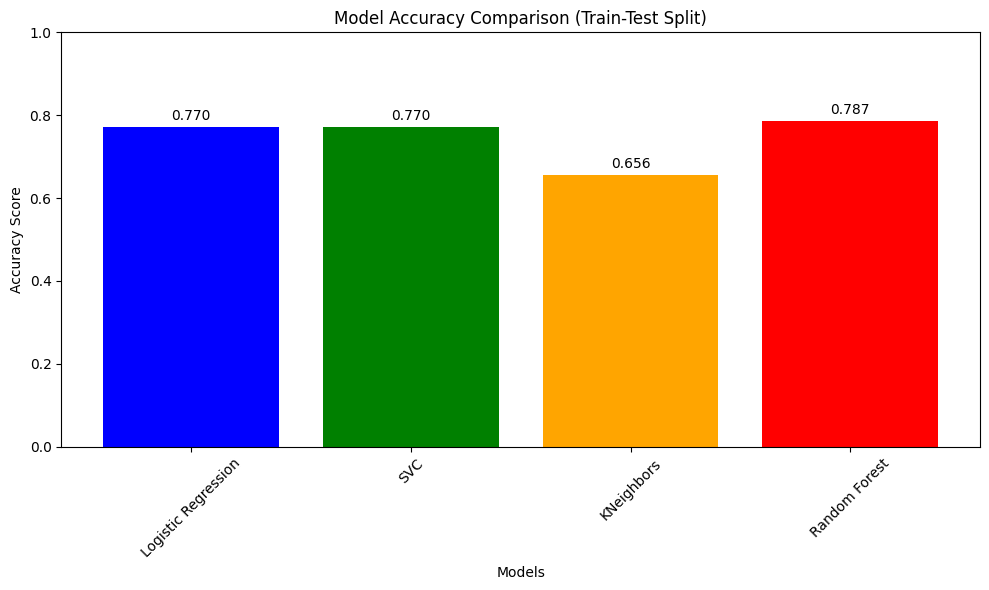

In [75]:
import matplotlib.pyplot as plt

# Get accuracy scores for train-test split models
model_names = ['Logistic Regression', 'SVC', 'KNeighbors', 'Random Forest']
accuracies = []

for model in models:
    model.fit(X_train, Y_train)
    test_data_prediction = model.predict(X_test)
    accuracy = accuracy_score(Y_test, test_data_prediction)
    accuracies.append(accuracy)

# Create bar plot
plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracies, color=['blue', 'green', 'orange', 'red'])
plt.title('Model Accuracy Comparison (Train-Test Split)')
plt.xlabel('Models')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)

# Add accuracy values on top of bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

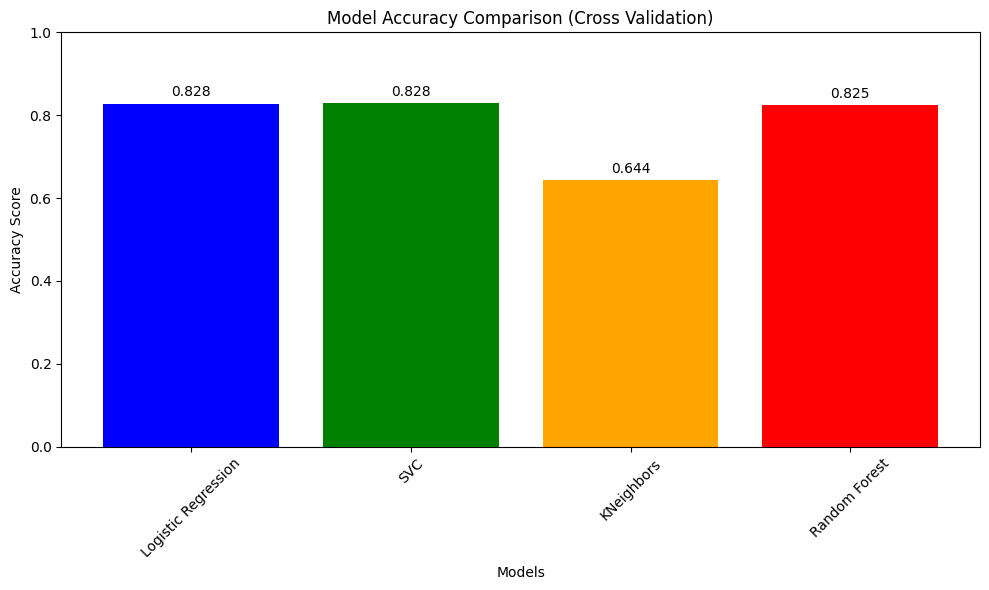

In [76]:
# Get cross-validation accuracy scores for all models
cv_accuracies = []
for model in models:
    cv_score = cross_val_score(model, X, Y, cv=5)
    mean_accuracy = sum(cv_score)/len(cv_score)
    cv_accuracies.append(mean_accuracy)

# Create bar plot for cross-validation accuracies
plt.figure(figsize=(10, 6))
plt.bar(model_names, cv_accuracies, color=['blue', 'green', 'orange', 'red'])
plt.title('Model Accuracy Comparison (Cross Validation)')
plt.xlabel('Models')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)

# Add accuracy values on top of bars
for i, v in enumerate(cv_accuracies):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

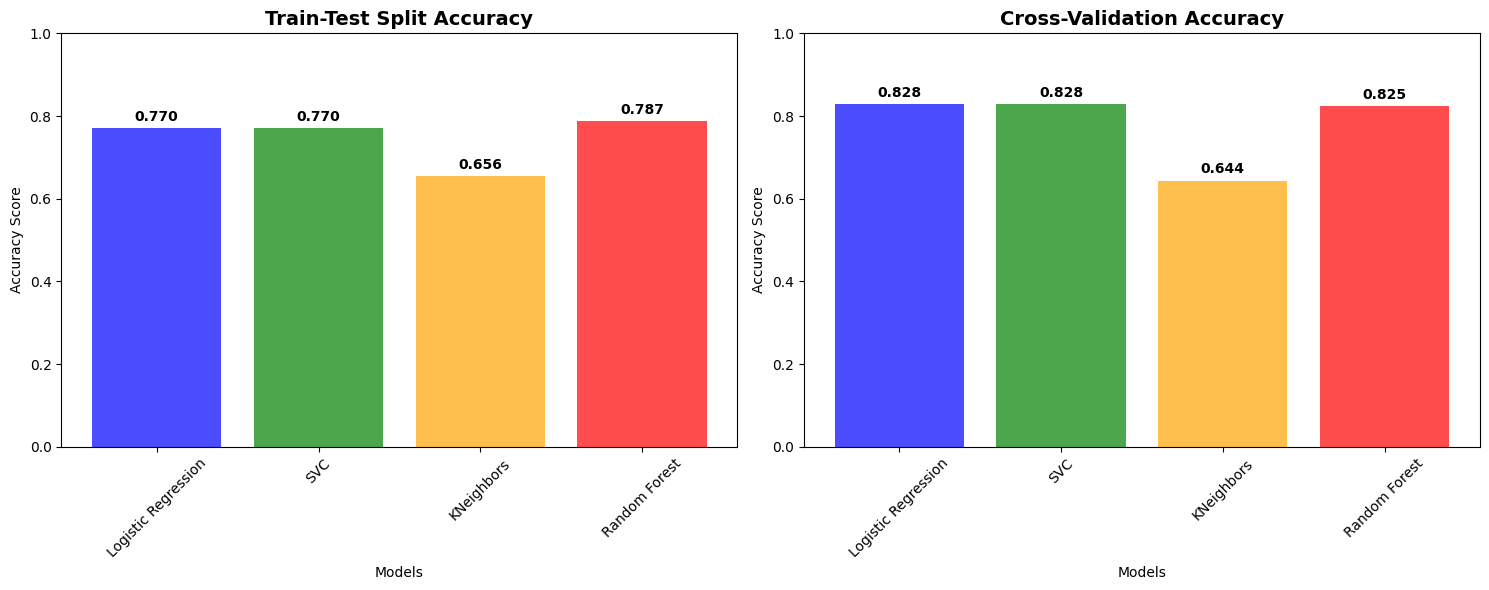

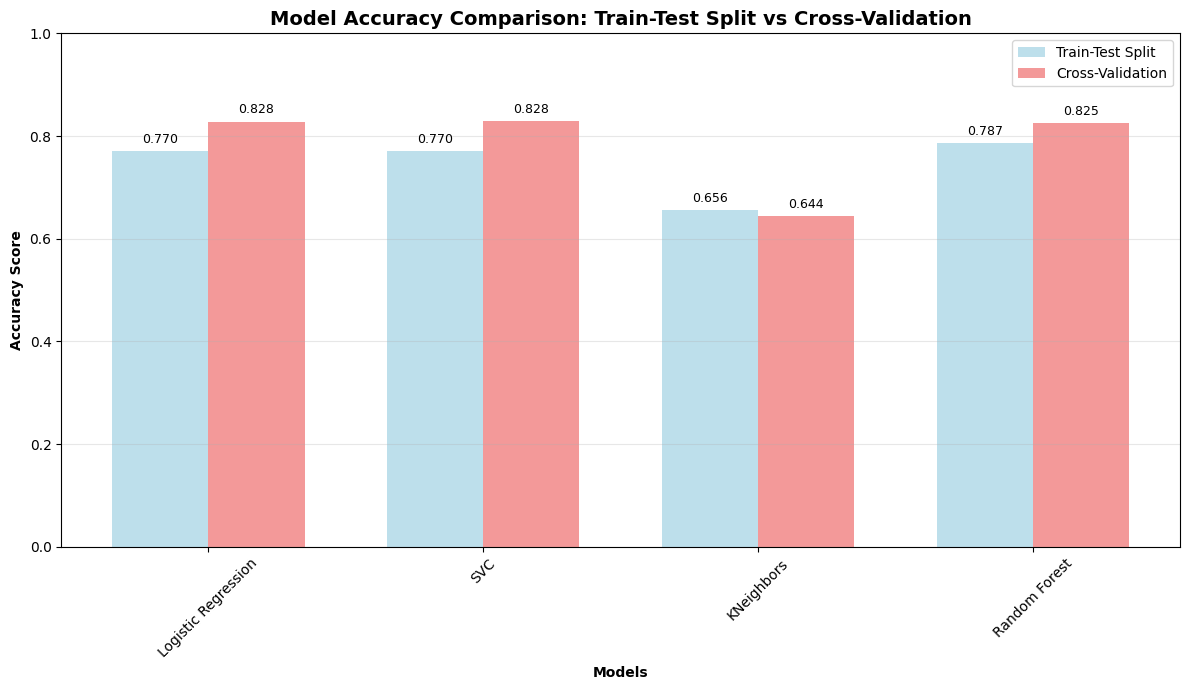

In [77]:
# Create side-by-side comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Train-Test Split Accuracies
ax1.bar(model_names, accuracies, color=['blue', 'green', 'orange', 'red'], alpha=0.7)
ax1.set_title('Train-Test Split Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Models')
ax1.set_ylabel('Accuracy Score')
ax1.set_ylim(0, 1)
ax1.tick_params(axis='x', rotation=45)

# Add accuracy values on top of bars
for i, v in enumerate(accuracies):
    ax1.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Cross-Validation Accuracies
ax2.bar(model_names, cv_accuracies, color=['blue', 'green', 'orange', 'red'], alpha=0.7)
ax2.set_title('Cross-Validation Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Models')
ax2.set_ylabel('Accuracy Score')
ax2.set_ylim(0, 1)
ax2.tick_params(axis='x', rotation=45)

# Add accuracy values on top of bars
for i, v in enumerate(cv_accuracies):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Create comparison plot showing both methods
plt.figure(figsize=(12, 7))
x_pos = np.arange(len(model_names))
width = 0.35

plt.bar(x_pos - width/2, accuracies, width, label='Train-Test Split', alpha=0.8, color='lightblue')
plt.bar(x_pos + width/2, cv_accuracies, width, label='Cross-Validation', alpha=0.8, color='lightcoral')

plt.xlabel('Models', fontweight='bold')
plt.ylabel('Accuracy Score', fontweight='bold')
plt.title('Model Accuracy Comparison: Train-Test Split vs Cross-Validation', fontsize=14, fontweight='bold')
plt.xticks(x_pos, model_names, rotation=45)
plt.legend()
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

# Add accuracy values on top of bars
for i, (acc1, acc2) in enumerate(zip(accuracies, cv_accuracies)):
    plt.text(i - width/2, acc1 + 0.01, f'{acc1:.3f}', ha='center', va='bottom', fontsize=9)
    plt.text(i + width/2, acc2 + 0.01, f'{acc2:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()